# Linear Regression from Scratch

The aim of this notebook is to implement the **linear regression** algorithm from scratch using only NumPy.

## 1. Classical Linear Regression

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Generate synthetic dataset
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3X + Gaussian noise

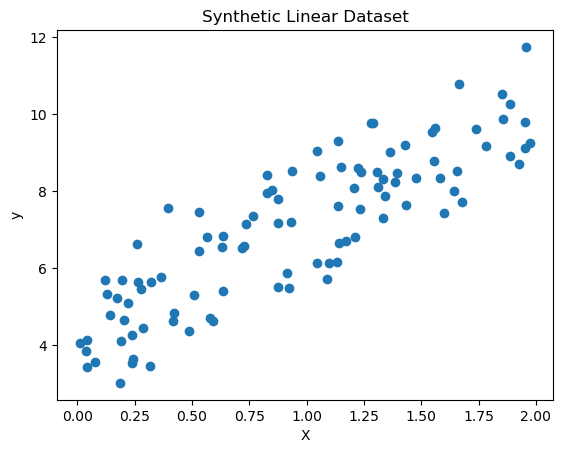

In [3]:
# Visualize the dataset
plt.scatter(X,y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Linear Dataset")
plt.show()

In [4]:
# Initialize parameters w and b
n_samples, n_features = X.shape
w = np.zeros(n_features)
b = 0

In [5]:
# Estimate y_hat using the linear model (foward pass)
y_hat = np.dot(X, w) + b

In [6]:
print("Shape of y_hat:", y_hat.shape)
print("Shape of X:", X.shape)
print("Shape of w:", w.shape)
print("Shape of y", y.shape)
print("Shape of y_hat - y.squeeze():", (y_hat - y.squeeze()).shape)

Shape of y_hat: (100,)
Shape of X: (100, 1)
Shape of w: (1,)
Shape of y (100, 1)
Shape of y_hat - y.squeeze(): (100,)


In [7]:
# Mean Squared Error Loss
mse_loss = np.mean((y_hat - y.squeeze()) **2)
print("MSE Loss:", mse_loss)

MSE Loss: 53.330318695242276


In [8]:
# Gradient Descent (backward pass)
dL_dw = (2/n_samples) * np.dot(X.T, (y_hat - y.squeeze()))
dL_db = (2/n_samples) * np.sum(y_hat - y.squeeze())

In [9]:
print("Gradient w.r.t w:", dL_dw)
print("Gradient w.r.t b:", dL_db)

Gradient w.r.t w: [-15.26711603]
Gradient w.r.t b: -14.058194762304462


The model predicts zero everywhere, but the true values of y are positive. So y_hat - y is negative for all examples. A negative gradient means that the loss decreases as you increase w and b—in other words, the model is telling you to increase both parameters to get closer to the true values.

That’s exactly what we expect. The sign makes sense.

In [10]:
# Update step
learning_rate = 0.01
w -= learning_rate * dL_dw
b -= learning_rate * dL_db

In [11]:
print("w after update:", w)
print("b after update:", b)

w after update: [0.15267116]
b after update: 0.14058194762304463


In [12]:
# Recompute y_hat and MSE Loss after update
y_hat = np.dot(X, w) + b

In [13]:
mse_loss_after_update = np.mean((y_hat - y.squeeze()) **2)
print("MSE Loss after update:", mse_loss_after_update)

MSE Loss after update: 49.11208555114041


The loss dropped from 53.33 to 49.11 in a single step. The training is working.

Both w and b increased, which is consistent with the negative gradients we calculated.

In [14]:
# Training loop
n_iterations = 1000
loss_history = []

for _ in range(n_iterations):
    # Forward pass
    y_hat = np.dot(X, w) + b
    
    # Compute loss
    mse_loss = np.mean((y_hat - y.squeeze()) **2)
    
    # Backward pass
    dL_dw = (2/n_samples) * np.dot(X.T, (y_hat - y.squeeze()))
    dL_db = (2/n_samples) * np.sum(y_hat - y.squeeze())

    # Update parameters
    w -= learning_rate * dL_dw
    b -= learning_rate * dL_db

    # Store loss history
    loss_history.append(mse_loss)

In [15]:
# Final parameters and loss
print("Final w:", w)
print("Final b:", b)

y_hat = np.dot(X, w) + b
final_mse_loss = np.mean((y_hat - y.squeeze()) **2)
print("Final MSE Loss:", final_mse_loss)

Final w: [2.99973533]
Final b: 4.186912973468354
Final MSE Loss: 0.99279586554016


The model learned:

- w ≈ 3.0 — the true value was 3
- b ≈ 4.19 — the true value was 4
- MSE Loss: 53.33 → 0.99

The model estimated the true parameters of the dataset almost exactly, based solely on the data.

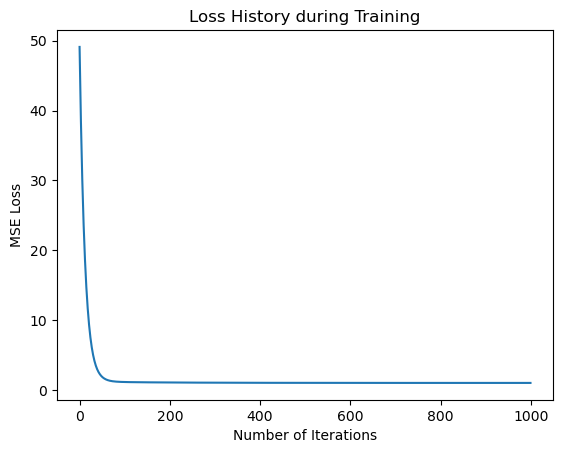

In [16]:
# Visualize the loss history
plt.plot(loss_history)
plt.xlabel("Number of Iterations")
plt.ylabel("MSE Loss")
plt.title("Loss History during Training")
plt.show()

The curve has the characteristic shape of a gradient descent process that is working well—a rapid drop at the beginning, followed by a gradual convergence toward a stable plateau.

Two things to note:
1. The loss drops dramatically in the first 100 iterations, then stabilizes. This suggests that 1,000 iterations may be more than necessary for this simple dataset—the model essentially converged by iteration 200.

2. The curve is smooth, with no oscillations. This is a sign that the learning rate of 0.01 is well-calibrated—neither too large nor too small.

In [17]:
# Evaluate the model on the training data
R_squared = 1 - (np.sum((y.squeeze() - y_hat) ** 2) / np.sum((y.squeeze() - np.mean(y.squeeze())) ** 2))
print("R-squared on training data:", R_squared)

R-squared on training data: 0.7468719148056457


At the beginning, `np.random.randn(100, 1)` is random Gaussian noise. By definition, no linear model can predict random noise—it is information that does not exist in X.
So R² breaks down as follows:

- 0.75 → variance explained by the actual linear relationship between X and y
- 0.25 → variance due to noise, which is unexplainable

An R² of 1.0 on this dataset would mean that the model has memorized the noise—that would be overfitting, which is not a good sign.

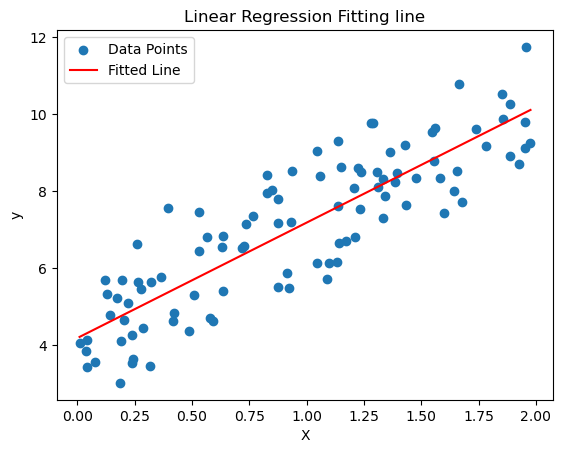

In [19]:
# Visualize the dataset and the fitted line
plt.scatter(X, y, label="Data Points")
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = np.dot(x_line, w) + b

plt.plot(x_line, y_line, color='red', label="Fitted Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Fitting line")
plt.legend()
plt.show()

## 2. Batch Variants

### 2.1. Full-Batch 

See the classical linear regularization above.

### 2.2. Stochastic Gradient Descent (SGD)

In [25]:
# Training loop
n_iterations = 1000
loss_history_stochastic = []

for _ in range(n_iterations):
    # Randomly selecting a random sample index for stochastic gradient descent
    i = np.random.randint(0, 100)

    # Forward pass
    y_hat = X[i] * w + b
    
    # Compute loss
    mse_loss = (y_hat - y.squeeze()[i]) ** 2
    
    # Backward pass
    dL_dw = 2 * X[i] * (y_hat - y.squeeze()[i])
    dL_db = 2 * (y_hat - y.squeeze()[i])

    # Update parameters
    w -= learning_rate * dL_dw
    b -= learning_rate * dL_db

    # Store loss history
    loss_history_stochastic.append(mse_loss)

In [26]:
# Final parameters and loss
print("Final w:", w)
print("Final b:", b)

Final w: [2.90854613]
Final b: [4.35068752]


When w ≈ 3 and b ≈ 4, the model estimated the true parameters just as it did with full-batch training.

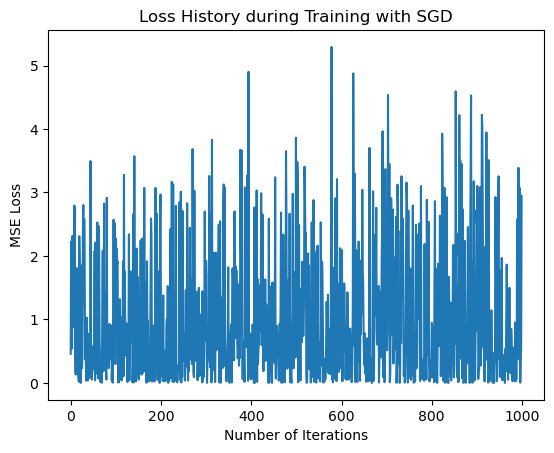

In [27]:
# Visualize the loss history
plt.plot(loss_history_stochastic)
plt.xlabel("Number of Iterations")
plt.ylabel("MSE Loss")
plt.title("Loss History during Training with SGD")
plt.show()

Despite constant fluctuations, the loss goes up and down with each iteration. Yet w and b have converged to the correct values.

Why? Because with each iteration, you use a single randomly selected example—the gradient is noisy, but on average it points in the right direction. The model still learns, but the path is chaotic.

### 2.3. Mini-Batch Gradient Descent

In [29]:
# Training loop
n_iterations = 100
batch_size = 32
loss_history_mini_batch = []

for _ in range(n_iterations):
    # Randomly selecting a batch of samples for mini-batch gradient descent
    batch_indices = np.random.permutation(n_samples)[:batch_size]

    # Forward pass
    y_hat = np.dot(X[batch_indices], w) + b

    # Compute loss
    mse_loss = np.mean((y_hat - y.squeeze()[batch_indices]) ** 2)

    # Backward pass
    dL_dw = (2/batch_size) * np.dot(X[batch_indices].T, (y_hat - y.squeeze()[batch_indices]))
    dL_db = (2/batch_size) * np.sum(y_hat - y.squeeze()[batch_indices])

    # Update parameters
    w -= learning_rate * dL_dw
    b -= learning_rate * dL_db

    # Store loss history
    loss_history_mini_batch.append(mse_loss)

In [30]:
# Final parameters and loss
print("Final w:", w)
print("Final b:", b)

Final w: [2.89824417]
Final b: [4.28795589]


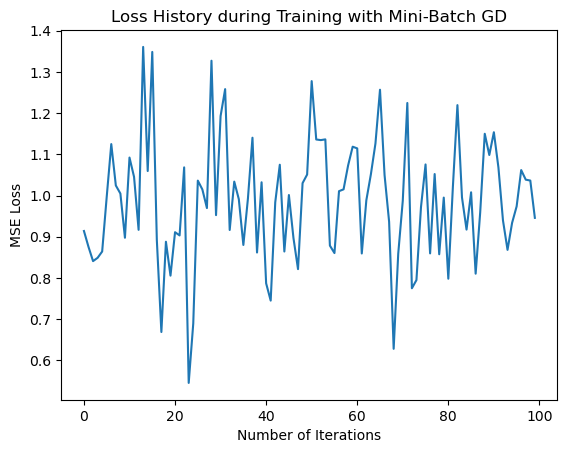

In [31]:
# Visualize the loss history
plt.plot(loss_history_mini_batch)
plt.xlabel("Number of Iterations")
plt.ylabel("MSE Loss")
plt.title("Loss History during Training with Mini-Batch GD")
plt.show()

Comparison of the 3 gradient descent methods:

- **Full-batch**: smooth, monotonically decreasing curve, no oscillations, but each update uses 100 examples.
- **SGD**: violent oscillations between 0 and 5, very noisy, one example per update.
- **Mini-batch**: moderate oscillations between 0.6 and 1.4, much more stable than SGD but still with some noise. And w ≈ 2.9, b ≈ 4.3. The model converged to the correct values in just 100 iterations.

This is exactly why mini-batch is the standard in practice: it benefits from the stability of full-batch and the speed of SGD.

## 3. Regularization

### 3.1. Ridge (L2)

In [41]:
# Training loop
n_iterations = 1000
lambda_ = 0.1
loss_history_l2 = []

for _ in range(n_iterations):
    # Forward pass
    y_hat = np.dot(X, w) + b
    
    # Compute loss
    mse_loss = np.mean((y_hat - y.squeeze()) **2) + lambda_ * np.sum(w**2)
    
    # Backward pass
    dL_dw = (2/n_samples) * np.dot(X.T, (y_hat - y.squeeze())) + 2 * lambda_ * w
    dL_db = (2/n_samples) * np.sum(y_hat - y.squeeze())

    # Update parameters
    w -= learning_rate * dL_dw
    b -= learning_rate * dL_db

    # Store loss history
    loss_history_l2.append(mse_loss)

In [42]:
# Final parameters and loss
print("Final w:", w)
print("Final b:", b)

Final w: [2.25917912]
Final b: [4.89838337]


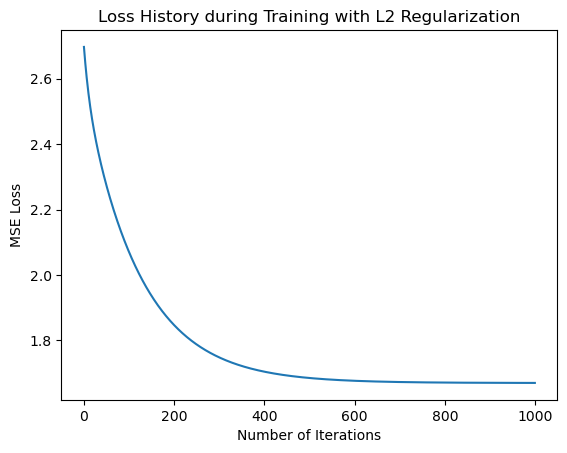

In [43]:
# Visualize the loss history
plt.plot(loss_history_l2)
plt.xlabel("Number of Iterations")
plt.ylabel("MSE Loss")
plt.title("Loss History during Training with L2 Regularization")
plt.show()

The curve converges nicely—smooth shape, no oscillations, just like the full-batch model.

| Model                   | w    | b    |
|-------------------------|------|------|
| Without regularization  | ≈ 3.0 | ≈ 4.19 |
| Ridge (λ = 0.1)         | ≈ 2.28 | ≈ 4.87 |

w has been shrunk to zero: this is exactly the Ridge effect described in theory.md. The model sacrifices a little accuracy on the training data to keep the weights small.

In addition, the larger lambda_ is, the closer w gets to zero. With lambda_ = 1.0, w went from 2.28 to 0.74. The model is becoming increasingly constrained.

This is a concrete demonstration of what theory.md says: a lambda_ that is too large leads to underfitting—the model can no longer learn the true relationship in the data.

### 3.2. Lasso (L1)

In [48]:
# Training loop
n_iterations = 1000
lambda_ = 0.1
loss_history_l1 = []

for _ in range(n_iterations):
    # Forward pass
    y_hat = np.dot(X, w) + b
    
    # Compute loss
    mse_loss = np.mean((y_hat - y.squeeze()) **2) + lambda_ * np.sum(np.abs(w))
    
    # Backward pass
    dL_dw = (2/n_samples) * np.dot(X.T, (y_hat - y.squeeze())) + lambda_ * np.sign(w)
    dL_db = (2/n_samples) * np.sum(y_hat - y.squeeze())

    # Update parameters
    w -= learning_rate * dL_dw
    b -= learning_rate * dL_db

    # Store loss history
    loss_history_l1.append(mse_loss)

In [49]:
# Final parameters and loss
print("Final w:", w)
print("Final b:", b)

Final w: [2.77021721]
Final b: [4.41829565]


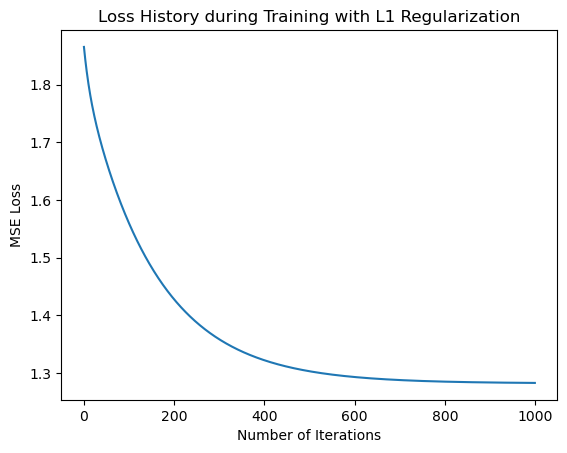

In [50]:
# Visualize the loss history
plt.plot(loss_history_l1)
plt.xlabel("Number of Iterations")
plt.ylabel("MSE Loss")
plt.title("Loss History during Training with L1 Regularization")
plt.show()

The curve converges nicely.

Comparison of the 3 models:

| Model             | w      | b      |
|-------------------|--------|--------|
| No regularization |  3.0  |  4.19 |
| Ridge (L2)        |  2.28 |  4.87 |
| Lasso (L1)        | 2.77 |  4.42 |

Both regularizations shrink w toward zero, but Ridge pushes it harder than Lasso with the same lambda_ = 0.1. 

This is consistent with the theory L2 penalizes large weights more aggressively because it uses the square.

On a single-feature dataset like this one, Lasso will not push w down to exactly zero. Lasso's feature selection effect really becomes apparent when we have many features and some of which are useless.